In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
# Experimantal Data
p = 9.4/1000 # pitch
d = 22/1000 # mean diameter of screw
D = 17.1/100 # diameter of drum

W = np.array([1,2,3,4,5]) #lb
f_lower = np.array([204.3,227.0,295.1,317.8,340.5]) #g
f_raise = np.array([281.6,327.0,427.0,485.9,540.5]) #g

In [25]:
exp_data = pd.DataFrame({
    'W (lb)':W,
    'P1 Lowering (g)':f_lower,
    'P1 raising (g)':f_raise
})
exp_data

,W (lb),P1 Lowering (g),P1 raising (g)
0,1,204.3,281.6
1,2,227.0,327.0
2,3,295.1,427.0
3,4,317.8,485.9
4,5,340.5,540.5


In [26]:
# Analysis
W = np.array([1,2,3,4,5])*0.453592*9.81 #N
f_lower = np.array([204.3,227.0,295.1,317.8,340.5])/1000*9.81 #N
f_raise = np.array([281.6,327.0,427.0,485.9,540.5])/1000*9.81 #N

tan_a = p/(np.pi*d) # tan(alpha)
T_raise = f_raise*D/2
T_lower = f_lower*D/2

P_raise = T_raise/(d/2)
P_lower = T_lower/(d/2)

efficiency_raise = W*p/(2*np.pi*T_raise)*100
efficiency_lower = W*p/(2*np.pi*T_lower)*100

mu_raise = (2*T_raise/W - d*tan_a)/(2*T_raise/W*tan_a+d)
mu_lower = (d*tan_a - 2*T_lower/W)/(2*T_lower/W*tan_a+d)

In [27]:
# Analysis Table
anal_data_raise = pd.DataFrame({
    'W (N)': W,
    'P1 raising (N)': f_raise,
    'Torque raising (Nm)': T_raise,
    'P2 raising (N)': P_raise,
    'Efficiency raising (%)': efficiency_raise,
    'mu raising': mu_raise
})
anal_data_raise

,W (N),P1 raising (N),Torque raising (Nm),P2 raising (N),Efficiency raising (%),mu raising
0,4.449738,2.762496,0.236193,21.472128,2.818478,2.831313
1,8.899475,3.207870,0.274273,24.933899,4.854332,1.930215
2,13.349213,4.188870,0.358148,32.558944,5.576229,1.729352
3,17.798950,4.766679,0.407551,37.050096,6.533717,1.516307
4,22.248688,5.302305,0.453347,41.213371,7.342121,1.370990


In [28]:
# Analysis Table
anal_data_lower = pd.DataFrame({
    'W (N)': W,
    'P1 lowering (N)': f_lower,
    'Torque lowering (Nm)': T_lower,
    'P2 lowering (N)': P_lower,
    'Efficiency lowering (%)': efficiency_lower,
    'mu lowering': mu_lower
})
anal_data_lower

,W (N),P1 lowering (N),Torque lowering (Nm),P2 lowering (N),Efficiency lowering (%),mu lowering
0,4.449738,2.004183,0.171358,21.472128,3.884891,-2.279510
1,8.899475,2.226870,0.190397,24.933899,6.992805,-1.430522
2,13.349213,2.894931,0.247517,32.558944,8.068621,-1.260605
3,17.798950,3.117618,0.266556,37.050096,9.989721,-1.033988
4,22.248688,3.340305,0.285596,41.213371,11.654674,-0.889740


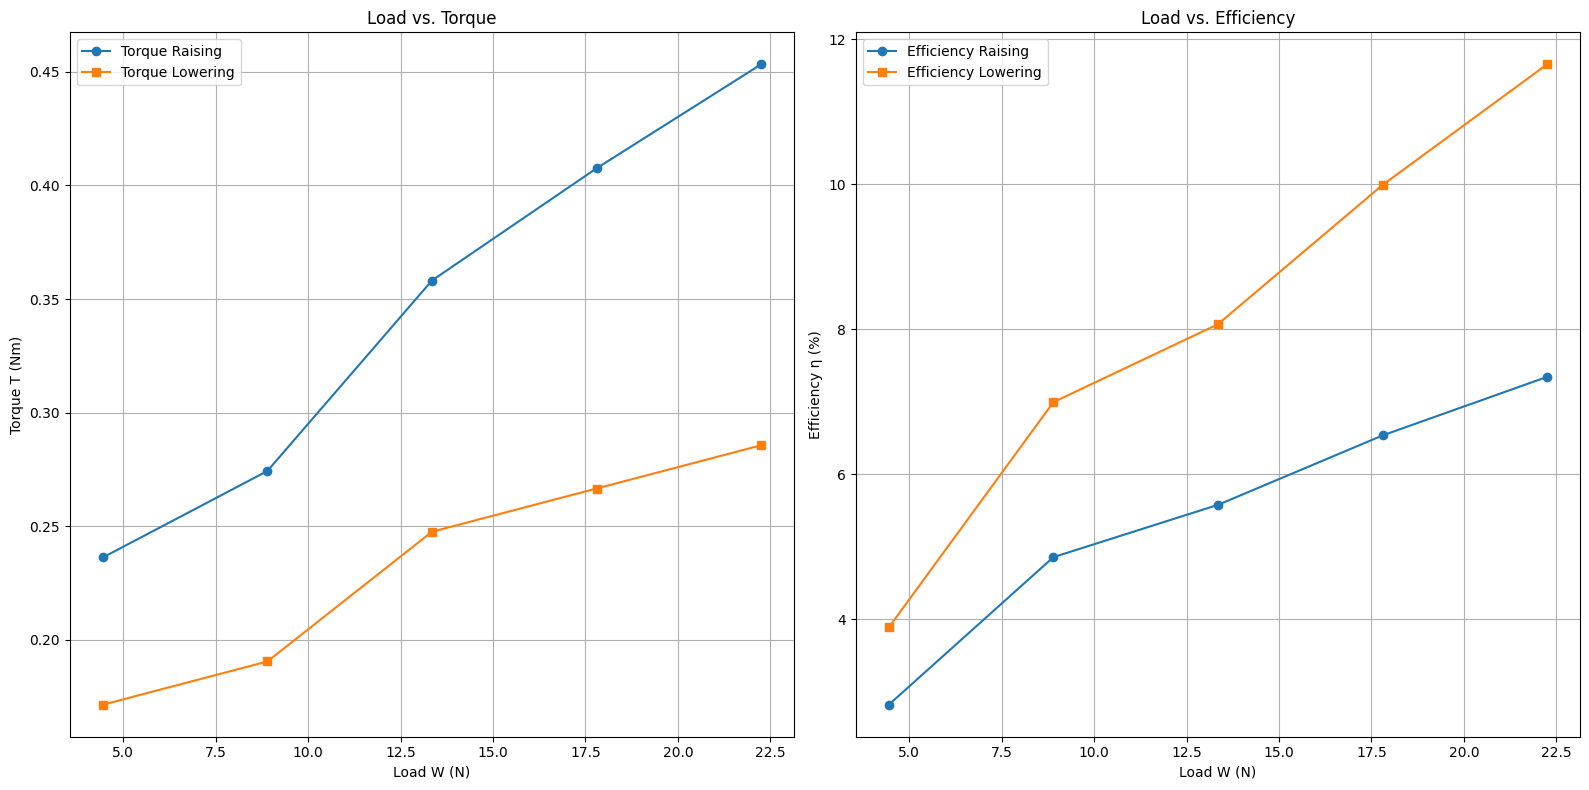

In [30]:
# Figure 1: Load vs. Torque (Raising and Lowering)
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(W, T_raise, 'o-', label='Torque Raising')
plt.plot(W, T_lower, 's-', label='Torque Lowering')
plt.xlabel('Load W (N)')
plt.ylabel('Torque T (Nm)')
plt.title('Load vs. Torque')
plt.legend()
plt.grid(True)

# Figure 2: Load vs. Efficiency
plt.subplot(1, 2, 2)
plt.plot(W, efficiency_raise, 'o-', label='Efficiency Raising')
plt.plot(W, efficiency_lower, 's-', label='Efficiency Lowering')
plt.xlabel('Load W (N)')
plt.ylabel('Efficiency η (%)')
plt.title('Load vs. Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()